# Cellpin Label Transfer Tutorial

Cellpin learns a robust embedding of scRNA-seq reference data, which makes it well suited for
**label transfer**: assigning cell-type annotations from an annotated reference to unlabelled
spatial cells. `label_transfer` fits a kNN classifier in cellpin's latent space on the annotated
reference and applies it to the spatial cells, so there is no second training run and no separate
integration step.

This notebook uses the **same two datasets as the [Denoising Xenium data](xenium_denoising.ipynb)
tutorial**, a 10x Xenium human lung cancer section and the Salcher et al. NSCLC reference atlas, so
you can run either notebook against the same files.

Here we transfer `ann_coarse`, the atlas's **coarse** annotation level. These are broad compartments rather than fine-grained cell states, which makes them the robust place to start. For the finer `cell_type`
annotation on this identical section, see [Denoising Xenium data](xenium_denoising.ipynb).

**Before running:** update `XENIUM_DIR` and `SC_PATH` in the *Load data* cell.

## Setup

In [26]:
from time import time

import cellpin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata_io
import torch

`spatialdata_io` is not a cellpin dependency. Install it alongside the `spatial` extra:

```bash
pip install "cellpin[spatial]" spatialdata-io
```

We only need the reader here, to pull the Xenium output folder into an `AnnData`. The denoising
tutorial additionally renders the `cell_boundaries` polygons and needs `spatialdata-plot`.

## Helper function

`normalize_by_cell_area`: Xenium counts scale with how much cell a polygon captured, so we normalise
by segmented area rather than by library size. This is the same normalisation cellpin applies
internally when you pass `area_key="cell_area"` to `impute()`, which keeps the measured and imputed
layers directly comparable.

In [27]:
def normalize_by_cell_area(adata, target_sum=1e3, key="cell_area"):
    """Scale each cell's counts to a fixed transcripts-per-unit-area budget, in place."""
    if key not in adata.obs:
        raise ValueError(f"{key!r} not found in adata.obs")

    cell_area = adata.obs[key].to_numpy(dtype=np.float64)
    if np.any(cell_area <= 0):
        raise ValueError("All cell areas must be positive.")

    scale_factors = (target_sum / cell_area)[:, np.newaxis]
    if hasattr(adata.X, "multiply"):
        adata.X = adata.X.multiply(scale_factors).tocsr()
    else:
        adata.X = adata.X * scale_factors

---
# 1) Load data

**Spatial**: [10x Genomics FFPE Human Lung Cancer, Xenium multimodal cell segmentation](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard).

**Reference**: the [Salcher et al. extended non-small cell lung cancer atlas](https://doi.org/10.1016/j.ccell.2022.10.008),
subset to the Xenium panel plus 1,000 additional highly variable genes. Raw counts live in
`layers["count"]`, and `obs["dataset"]` identifies the contributing study, we pass it as `batch_key`
so cellpin conditions out study effects while learning the latent space.

`CELL_TYPE_COL` is the only knob that differs from the denoising tutorial: `ann_coarse` instead of
`cell_type`.

In [29]:
LAYER = "counts"             # layer holding raw integer counts in both objects
CELL_TYPE_COL = "ann_coarse"  # coarse annotation level in the reference
TABLE_KEY = "table"

XENIUM_DIR = "/data/spatial/10X_Xenium/Lung/FFPE_Human_Lung_Cancer_Xenium_Multimodal_Cell_Segmentation"  # update these paths
SC_PATH = "/data/scRNA/Lung/Salcher_et_al_ATLAS/adata_1000_genes.h5ad"  # update these paths

sdata = spatialdata_io.xenium(XENIUM_DIR)
sc_adata = sc.read_h5ad(SC_PATH)
sc.pp.subsample(sc_adata, n_obs=100_000) #we subsample for speed

sc_adata.layers["counts"] = sc_adata.layers["count"]  # this atlas stores raw counts as "count"

print(f"sc_adata : {sc_adata.n_obs:,} cells x {sc_adata.n_vars:,} genes")
print(f"\nLabels in {CELL_TYPE_COL!r}:")
print(sc_adata.obs[CELL_TYPE_COL].value_counts())

/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/site-packages/spatialdata_io/_utils.py:59: UserWarning: Nucleus boundaries are not supported for this Xenium format version (v2.0.0 early builds without label_id in the parquet). The parquet merges multinucleate cells into degenerate polygons. Skipping nucleus boundaries. You can derive nucleus polygons from the raster labels using spatialdata.to_polygons(). See https://github.com/scverse/spatialdata-io/discussions/387 for details.
  return f(*args, **kwargs)


sc_adata : 100,000 cells x 1,351 genes

Labels in 'ann_coarse':
ann_coarse
Macrophage/Monocyte    29764
T cell                 26082
Epithelial cell        18923
NK cell                 5345
B cell                  5089
Endothelial cell        4332
cDC                     3340
Plasma cell             2229
Stromal                 2161
Mast cell               1549
Neutrophils              895
pDC                      291
Name: count, dtype: int64


## 1.1 Preprocess the Xenium table

We pull the table out of the `SpatialData` object and work with it as a plain `AnnData`. 

Three things happen here:

1. Keep the raw counts in `layers["counts"]`, because cellpin's negative-binomial likelihood needs them.
2. Build the **measured** reference layer `log1p_norm` (area-normalised, log1p). We use it below to
   check transferred labels against markers in the measured data, not just the imputed data.
3. Drop cells with fewer than 10 detected genes. These are mostly segmentation debris.

In [30]:
sp_adata = sdata.tables[TABLE_KEY]
sp_adata.obs_names = sp_adata.obs["cell_id"].astype(str)

sp_adata.layers["counts"] = sp_adata.X.copy()

normalize_by_cell_area(sp_adata, target_sum=1e3, key="cell_area")
sc.pp.log1p(sp_adata)
sp_adata.layers["log1p_norm"] = sp_adata.X.copy()

sc.pp.filter_cells(sp_adata, min_genes=10)
print(f"Section after filtering: {sp_adata.n_obs:,} cells x {sp_adata.n_vars:,} panel genes")

Section after filtering: 151,782 cells x 377 panel genes


## 1.2 Gene alignment check

Panel genes missing from the reference are silently dropped by `setup_data()`; worth knowing upfront
how large the panel and the imputation target actually are.

In [31]:
sp_genes = sp_adata.var_names
sc_genes = sc_adata.var_names

missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} panel genes are present in the reference")
else:
    print(f"WARNING: {len(missing)} panel gene(s) missing from the reference (will be dropped):")
    print(sorted(missing))

panel_genes = sp_genes.intersection(sc_genes)
print(f"\nPanel size (overlap)          : {len(panel_genes)} genes")
print(f"Reference-only genes to impute: {len(sc_genes) - len(panel_genes)} genes")

['ADIPOQ', 'AMY2A', 'APOA5', 'ASCL3', 'C1orf194', 'C20orf85', 'CCL27', 'CFHR1', 'CLCA1', 'CLECL1', 'FCN2', 'GCG', 'GLYATL1', 'GYPA', 'INS', 'KRT20', 'MLANA', 'MTRNR2L11', 'NAT8', 'OPRPN', 'SCGN', 'SLC22A8', 'SLC26A3', 'SST', 'TMEM174', 'UMOD']

Panel size (overlap)          : 351 genes
Reference-only genes to impute: 1000 genes


---
# 2) Train

`setup_data` aligns the two gene spaces and returns the dataset pair. Training is the usual two
stages:

1. **Stage 1 (pretrain):** full-gene VAE (ELBO on all reference genes)
2. **Stage 2 (distillation):** panel encoder aligned to the full encoder via MSE + SNN +
   reconstruction from the panel embedding

Nothing here is specific to label transfer. If you have already trained a model on this reference,
for instance by running the denoising tutorial, reuse it and skip to section 3.

In [32]:
sc_dataset, sp_dataset = cellpin.pp.setup_data(
    sc_adata,
    sp_adata,
    layer=LAYER,
    batch_key="dataset",  # recommended whenever the reference is a multi-study atlas
)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :  100,000 cells  ×    1,351 genes
[cellpin.pp.setup] st_adata :  151,782 cells  ×      377 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 26 spatial gene(s) not found in sc_adata — will be dropped:
  ['ADIPOQ', 'AMY2A', 'APOA5', 'ASCL3', 'C1orf194', 'C20orf85', 'CCL27', 'CFHR1', 'CLCA1', 'CLECL1'] ...
[cellpin.pp.setup] Panel    : 351 genes overlap (93.1% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,351 genes total in sc space (1,000 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 100,000 cells, 1,351 genes total, 351 panel genes
[cellpin.pp.setup] st_dataset: 151,782 cells, 351 panel genes


In [33]:
t0 = time()
model = cellpin.CellPin(sc_dataset)
model.fit(
    sc_dataset,
    pretrain_epochs=50,
    train_epochs=60,
    batch_size=512,
    save_checkpoints=False,
)
print(f"Training time: {(time() - t0) / 60:.2f} minutes")

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training time: 6.46 minutes


---
# 3) Impute

Imputation is **not** required for label transfer: `label_transfer` only needs the latent embedding,
and it will compute one on the fly if `obsm["X_cellpin"]` is absent. We run it explicitly because the
marker plots at the bottom compare measured against imputed expression.

`area_key="cell_area"` makes `imputed_norm` use the same area normalisation we applied to
`log1p_norm` above, so the two layers are on one scale and every side-by-side plot is honest.

In [35]:
t0 = time()
dl_sp = torch.utils.data.DataLoader(sp_dataset, batch_size=1024, shuffle=False)

adata = model.impute(
    dl_sp,
    obs_adata=sp_adata,
    return_norm=True,
    return_int=True,
    area_key="cell_area",
    nb_count_samples=20,
)
print(f"Imputation time: {(time() - t0) / 60:.2f} minutes")

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1000 gene(s) absent from obs_adata layers with 0
Imputation time: 0.59 minutes


---
# 4) Transfer the coarse labels

`label_transfer` fits a kNN classifier in cellpin's latent space on the annotated reference and
applies it to the section. It writes `obs["cellpin_annotation"]` and
`obs["cellpin_annotation_certainty"]`, and returns the held-out reference accuracy.

Pass `conf_threshold=` to assign `"Unknown"` when the predicted class probability falls below a
given threshold. That is usually what you want on tissue the reference does not fully cover.

In [36]:
accuracy, adata = cellpin.tl.label_transfer(
    model,
    sc_adata,
    CELL_TYPE_COL,
    adata,
)
adata.obs["cellpin_annotation"].value_counts()

[label_transfer] X_cellpin not found in sc_adata — embedding with default settings...
Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓

[label_transfer] 12 cell type classes
[label_transfer] Train: 80000 | Test: 20000
[label_transfer] Test accuracy: 0.9728
[label_transfer] Annotation complete. Annotations stored in sp_adata.obs['cellpin_annotation']


cellpin_annotation
Epithelial cell        89121
Stromal                17682
T cell                 16143
Macrophage/Monocyte    12768
Endothelial cell        6770
Plasma cell             3184
cDC                     2649
B cell                  2058
Mast cell               1137
NK cell                  130
Neutrophils              125
pDC                       15
Name: count, dtype: int64

**These are deliberately coarse labels.** `ann_coarse` splits the atlas into broad compartments, so
a call of "epithelial cell" here covers malignant cells, alveolar type 1 and type 2 cells, club
cells and multiciliated cells all at once. That is the right granularity when you want labels you
can trust for gating, QC or as a stable backdrop for a spatial analysis.

For the finer annotation, transfer `cell_type` instead of `ann_coarse` on this same section: the
[Denoising Xenium data](xenium_denoising.ipynb) tutorial does exactly that, and uses the resulting
per-cell-type resolution to show how much spurious B-cell signal sits in epithelial cells before
denoising.

The accuracy printed above is measured on held-out *reference* cells, so treat it as a sanity check
on the classifier rather than proof the labels are right in tissue. The marker checks below are the
real test, and they are worth running on your own data too.

## 4.1 Labels in tissue

/tmp/ipykernel_31675/600525749.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


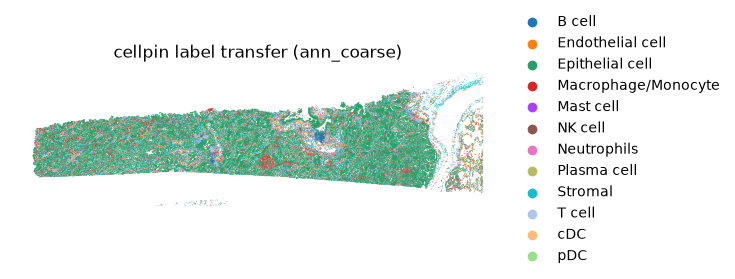

In [37]:
sc.pl.spatial(
    adata,
    color="cellpin_annotation",
    spot_size=15,
    frameon=False,
    title=f"cellpin label transfer ({CELL_TYPE_COL})",
)

## 4.2 UMAP from cellpin embeddings

Cell embeddings in `obsm["X_cellpin"]` can be used directly to build a neighbourhood graph and
compute a UMAP.

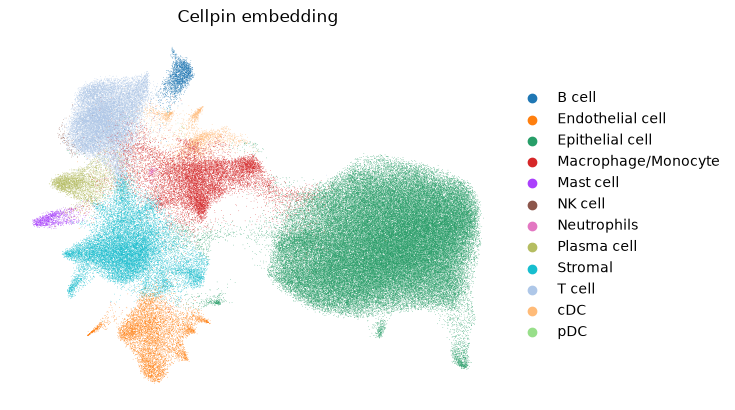

In [41]:
sc.pp.neighbors(adata, use_rep="X_cellpin", n_neighbors=50)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cellpin_annotation"], frameon=False, title="Cellpin embedding")

## 4.3 Marker check

Broad-compartment markers are the honest test of a coarse annotation: they should light up the
matching class and nothing else, in the **measured** counts as well as the imputed ones. (While measured counts are usually much messier though, due to missegementation etc.)

The next cell keeps only the markers that are actually in this panel, since `log1p_norm` exists for
panel genes only. Swap in whichever markers match the `ann_coarse` classes in your reference.

In [49]:
CANDIDATE_MARKERS = ["KIT", "CD3E", "CD79A", "MS4A1"] 
#KIT should be in Mast cells
#CD3E should be in T cells
#CD79A should be in B and Plasma cells
#MS4A1 should not be in Plasma cells but in B cells

MARKERS = [g for g in CANDIDATE_MARKERS if g in panel_genes]
dropped = [g for g in CANDIDATE_MARKERS if g not in panel_genes]
if dropped:
    print(f"Not in the panel, skipping: {dropped}")
print(f"Plotting: {MARKERS}")

Plotting: ['KIT', 'CD3E', 'CD79A', 'MS4A1']


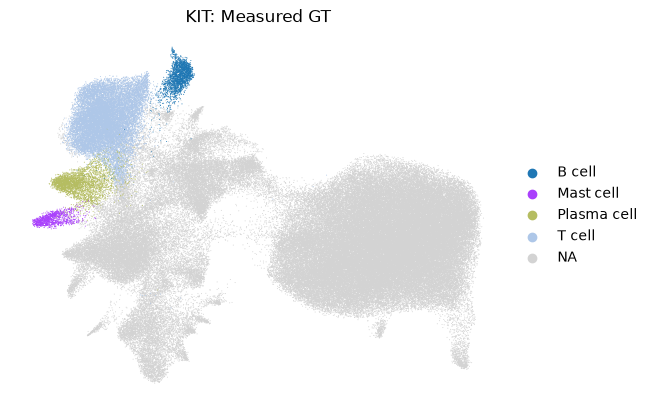

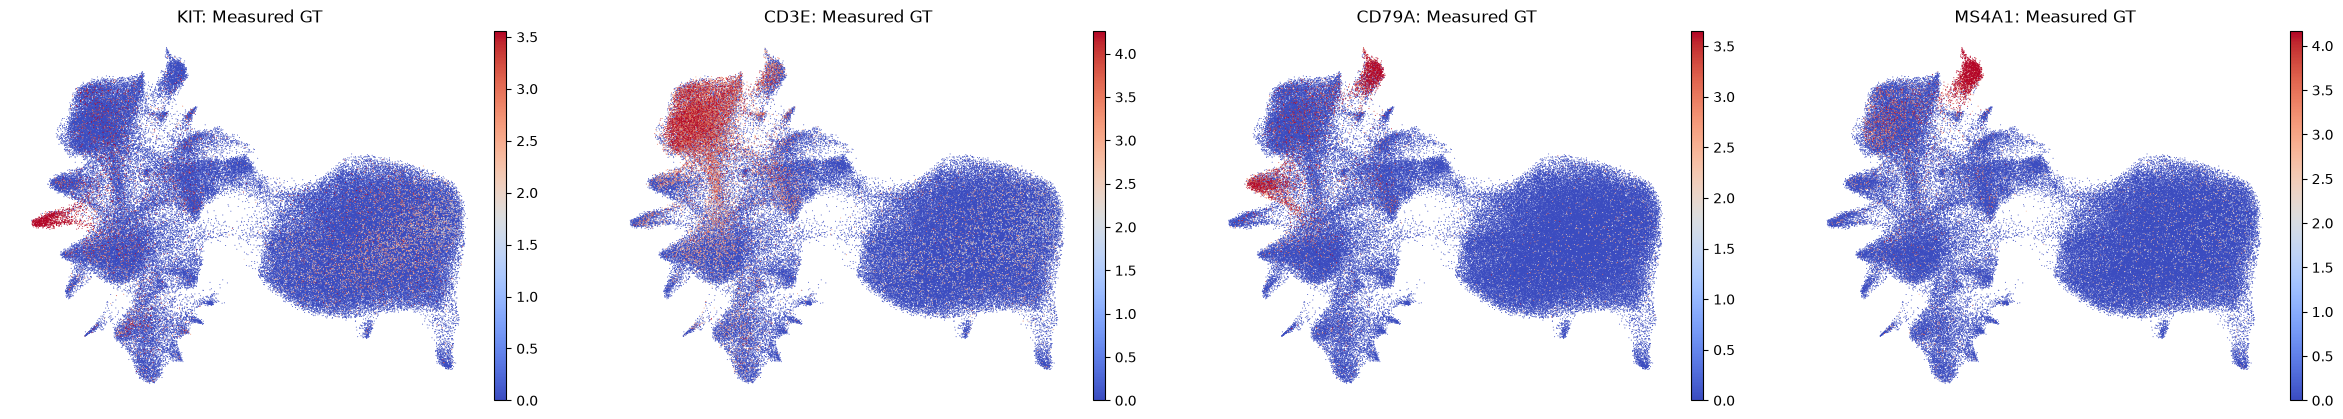

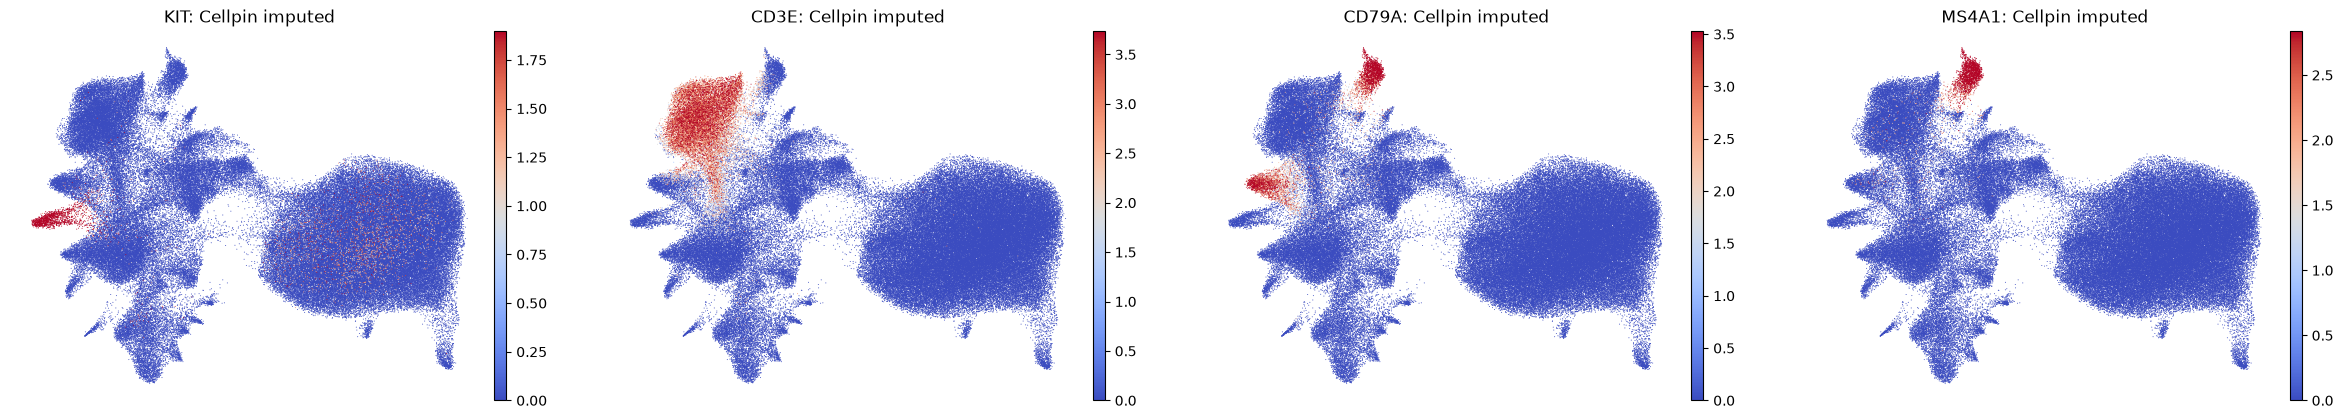

In [54]:
sc.pl.umap(
    adata,
    color=["cellpin_annotation"],
    groups=["T cell", "Mast cell", "B cell", "Plasma cell"],
    frameon=False,
    size=2,
    title=[f"{gene}: Measured GT" for gene in MARKERS],
)

sc.pl.umap(
    adata,
    color=MARKERS,
    frameon=False,
    vmax="p99",
    layer="log1p_norm",
    cmap="coolwarm",
    na_color="white",
    size=2,
    title=[f"{gene}: Measured GT" for gene in MARKERS],
)

sc.pl.umap(
    adata,
    color=MARKERS,
    frameon=False,
    vmax="p99",
    layer="imputed_norm",
    cmap="coolwarm",
    na_color="white",
    size=2,
    title=[f"{gene}: Cellpin imputed" for gene in MARKERS],
)

---
## Takeaways

- Label transfer reuses the model you already trained. `label_transfer` fits a kNN classifier in
  cellpin's latent space on the annotated reference and applies it to the spatial cells, so there is
  no second training run and no separate integration step.
- Transferring at a **coarse** level (`ann_coarse`) is the robust default: broad compartments are
  well separated in the latent space and well populated in the reference. Move to a finer column
  such as `cell_type` when your reference genuinely supports it, see
  [Denoising Xenium data](xenium_denoising.ipynb) for the same section annotated that way.
- The transferred labels hold up against known markers in the **measured** counts as well as the
  imputed ones. That is the check that matters; held-out reference accuracy is not.
- `conf_threshold=` routes ambiguous cells to an explicit `"Unknown"` class instead of forcing a
  call, which is usually what you want on tissue the reference does not fully cover.
- If your reference is not well annotated, marker-based annotation of Leiden clusters computed on
  the cellpin neighbourhood graph is an equally good and often better route, see
  [Best Practices](../best_practices.md).

Related tutorials: [Basic usage](cellpin_tutorial.ipynb) for the core imputation workflow, and
[Denoising Xenium data](xenium_denoising.ipynb) for what cellpin removes from measured counts.